# Top-10 Bancos Chilenos · perfil regulatorio + financiero

Notebook focalizado: tomamos los 10 bancos más usados del sistema chileno
y exprimimos cada endpoint del SDK `cerberus-compliance` para construir
un panorama 360° por banco — directorios, sanciones CMF, hechos
esenciales, **adecuación de capital (Basel III)**, accionistas, footprint
físico, cross-reference contra OFAC/UN/EU, y match semántico contra el
corpus documental.

**Portafolio analizado**

| # | Banco | RUT |
|---|---|---|
| 1 | BancoEstado | 97.030.000-7 |
| 2 | Banco de Chile | 97.004.000-5 |
| 3 | Banco Santander Chile | 97.036.000-K |
| 4 | BCI (Banco de Crédito e Inversiones) | 97.006.000-6 |
| 5 | Scotiabank Chile | 97.018.000-1 |
| 6 | Itaú Chile | 97.023.000-9 |
| 7 | Banco BICE | 97.080.000-K |
| 8 | Banco Falabella | 96.509.660-4 |
| 9 | Banco Consorcio | 99.500.410-0 |
| 10 | Banco Security | 97.053.000-2 ⚠️ corregido (`97.049.000-3` falla mod-11) |

**Buenas prácticas aplicadas en este notebook**

1. **Concurrencia limitada con `asyncio.Semaphore`** — el endpoint
   `/sanctions/cross-reference` corre fuzzy-match contra 4 listas
   internacionales y es CPU-bound; lanzar 10 en paralelo dispara
   back-pressure (500/503 → retries del SDK). Usamos
   `Semaphore(3)` para suavizar el burst sin sacrificar throughput.

2. **Logging del SDK silenciado en `WARNING`** — el SDK loguea cada retry
   automático como WARNING. Para mantener el output del notebook limpio
   subimos el threshold a `ERROR` (los errores de verdad sí se ven).

3. **Manejo defensivo de gaps de datos** — el backend de Cerberus
   alimenta sus tablas vía ingestores asincrónicos (GLEIF, CMF SBIF,
   directores, etc.) que pueden no haber alcanzado todos los RUTs. El
   notebook reporta cobertura explícita en lugar de fallar silenciosamente.


## 1 · Setup

In [1]:
from __future__ import annotations

import asyncio
import json
import logging
import os
from datetime import date, timedelta

import nest_asyncio; nest_asyncio.apply()
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

assert os.getenv("CERBERUS_API_KEY"), (
    "Set CERBERUS_API_KEY before running this notebook "
    "(e.g. `export CERBERUS_API_KEY=ck_live_…`)."
)

# Subir el threshold del logger del SDK a ERROR mantiene el notebook
# limpio (los retries y backoffs informativos son WARNING). Si querés
# debug detallado, bajalo a INFO.
logging.getLogger("cerberus_compliance").setLevel(logging.ERROR)

import cerberus_compliance
from cerberus_compliance import (
    AsyncCerberusClient,
    CerberusClient,
    SearchDateRange,
    SearchFilters,
)
print(f"SDK version: {cerberus_compliance.__version__}")

BANKS: list[tuple[str, str]] = [
    ("97030000-7", "BancoEstado"),
    ("97004000-5", "Banco de Chile"),
    ("97036000-K", "Banco Santander Chile"),
    ("97006000-6", "BCI"),
    ("97018000-1", "Scotiabank Chile"),
    ("97023000-9", "Itaú Chile"),
    ("97080000-K", "Banco BICE"),
    ("96509660-4", "Banco Falabella"),
    ("99500410-0", "Banco Consorcio"),
    ("97053000-2", "Banco Security"),
]
print(f"Portfolio: {len(BANKS)} bancos")


SDK version: 0.6.0
Portfolio: 10 bancos


## 2 · Helper de concurrencia con throttle

Empaqueta el patrón `Semaphore + gather` en una función reutilizable.
Cada llamada async pasa por el semáforo, así nunca hay más de
`concurrency` requests en vuelo a la vez.


In [2]:
async def gather_throttled(coro_factory, items, *, concurrency: int = 3):
    """Lanza ``coro_factory(item)`` para cada ``item``, máx ``concurrency`` simultáneos.

    Args:
        coro_factory: callable que recibe ``(client, item)`` y devuelve coroutine.
        items: iterable de inputs (uno por coroutine).
        concurrency: tope de fan-out simultáneo (3 evita back-pressure
            en endpoints expensive como /sanctions/cross-reference).

    Returns:
        list de resultados, en el mismo orden que ``items``.
    """
    sem = asyncio.Semaphore(concurrency)

    async def _wrapped(client, item):
        async with sem:
            return await coro_factory(client, item)

    async with AsyncCerberusClient() as c:
        return await asyncio.gather(*(_wrapped(c, item) for item in items))

print("gather_throttled() listo · concurrency default = 3")


gather_throttled() listo · concurrency default = 3


## 3 · Fetch async de los 10 perfiles KYB

`kyb.get(rut, include=["directors","lei","hechos_esenciales"])` une en una
sola llamada: identidad legal, directorio actual, LEI (si está poblado),
sanctions summary, y los últimos hechos esenciales.


In [3]:
async def fetch_kyb(c, item):
    rut, hint = item
    p = await c.kyb.get(rut=rut, include=["directors", "lei", "hechos_esenciales"])
    sa = p.get("sanctions") or {}
    return {
        "rut": rut,
        "hint": hint,
        "legal_name": p.get("legal_name"),
        "fantasy_name": p.get("fantasy_name"),
        "kind": p.get("entity_kind"),
        "status": p.get("status"),
        "size_bucket": p.get("size_bucket"),
        "inscription_date": p.get("inscription_date"),
        "lei": p.get("lei"),
        "risk_score": p.get("risk_score"),
        "risk_factors": p.get("risk_factors", []),
        "n_directors": len(p.get("directors_current") or []),
        "n_recent_events": len(p.get("recent_material_events") or []),
        "sanctions_total": sa.get("total_count"),
        "sanctions_vigentes": sa.get("vigentes_count"),
        "sanctions_historical": sa.get("historical_count"),
        "_directors": p.get("directors_current") or [],
        "_events": p.get("recent_material_events") or [],
    }

profiles = asyncio.run(gather_throttled(fetch_kyb, BANKS, concurrency=5))

df = pd.DataFrame(profiles)
df["inscription_date"] = pd.to_datetime(df["inscription_date"], errors="coerce")
df["age_years"] = ((pd.Timestamp.today() - df["inscription_date"]).dt.days / 365.25).round(1)
df[["hint", "legal_name", "kind", "status", "risk_score", "n_directors", "lei", "age_years"]]


,hint,legal_name,kind,status,risk_score,n_directors,lei,age_years
0,BancoEstado,BANCO DEL ESTADO DE CHILE,banco,vigente,45,11,NaN,NaN
1,Banco de Chile,Banco de Chile SA,banco,vigente,50,2,PVVK4N5A7MITLWQJQQ35,132.5
2,Banco Santander Chile,BANCO SANTANDER-CHILE,banco,vigente,25,2,NaN,NaN
3,BCI,BANCO DE CREDITO E INVERSIONES,banco,vigente,15,1,NaN,NaN
4,Scotiabank Chile,SCOTIABANK CHILE,banco,vigente,15,1,NaN,NaN
5,Itaú Chile,BANCO ITAÚ CHILE,banco,vigente,15,12,NaN,NaN
6,Banco BICE,BANCO BICE,banco,vigente,45,1,NaN,NaN
7,Banco Falabella,BANCO FALABELLA,banco,vigente,45,1,NaN,NaN
8,Banco Consorcio,BANCO CONSORCIO,banco,vigente,15,1,NaN,NaN
9,Banco Security,BANCO SECURITY,banco,no_vigente,45,0,NaN,NaN


## 4 · Risk score comparativo

Banda: 🟢 0–20 (bajo) · 🟡 21–50 (medio) · 🔴 51–100 (crítico).


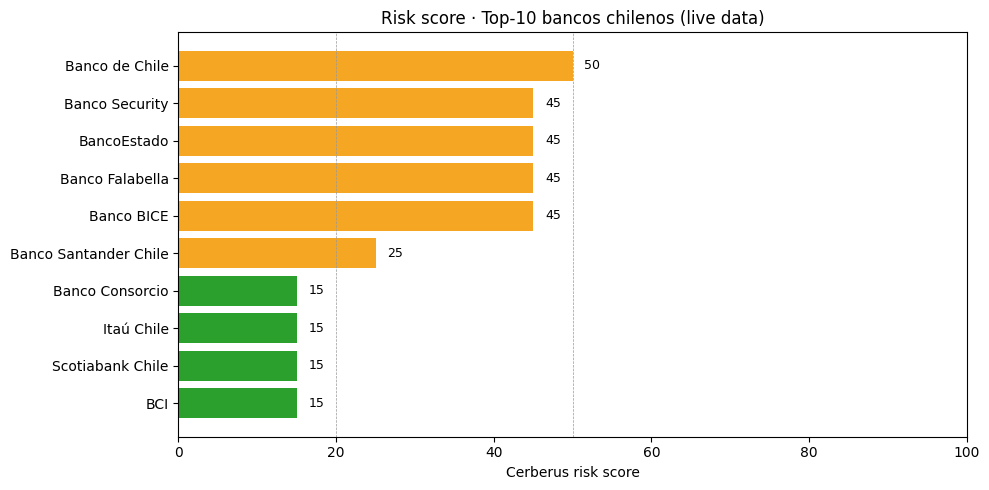

In [4]:
def _risk_color(s):
    if s is None: return "#999"
    if s <= 20:  return "#2ca02c"
    if s <= 50:  return "#f5a623"
    return "#d62728"

ordered = df.sort_values("risk_score")
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(ordered["hint"], ordered["risk_score"],
               color=[_risk_color(s) for s in ordered["risk_score"]])
for b, s in zip(bars, ordered["risk_score"]):
    ax.text(s + 1.5, b.get_y() + b.get_height()/2, f"{s}", va="center", fontsize=9)
ax.axvline(20, color="#999", lw=0.5, ls="--")
ax.axvline(50, color="#999", lw=0.5, ls="--")
ax.set_xlim(0, 100)
ax.set_xlabel("Cerberus risk score")
ax.set_title("Risk score · Top-10 bancos chilenos (live data)")
plt.tight_layout(); plt.show()


## 5 · Antigüedad regulatoria y cobertura LEI

Antigüedad = años desde `inscription_date` en CMF. La presencia de LEI
(Legal Entity Identifier global, registro GLEIF) es un proxy simple de
exposición a contraparte internacional.

> ⚠️ **Gap conocido**: en este momento el backend solo tiene materializado
> el LEI de Banco de Chile. La columna `entity.lei` se puebla por el
> `gleif_refresh` async, que no ha completado su run para los demás
> bancos del set. La sección §6 verifica esto cruzando con
> `entities.ownership`.


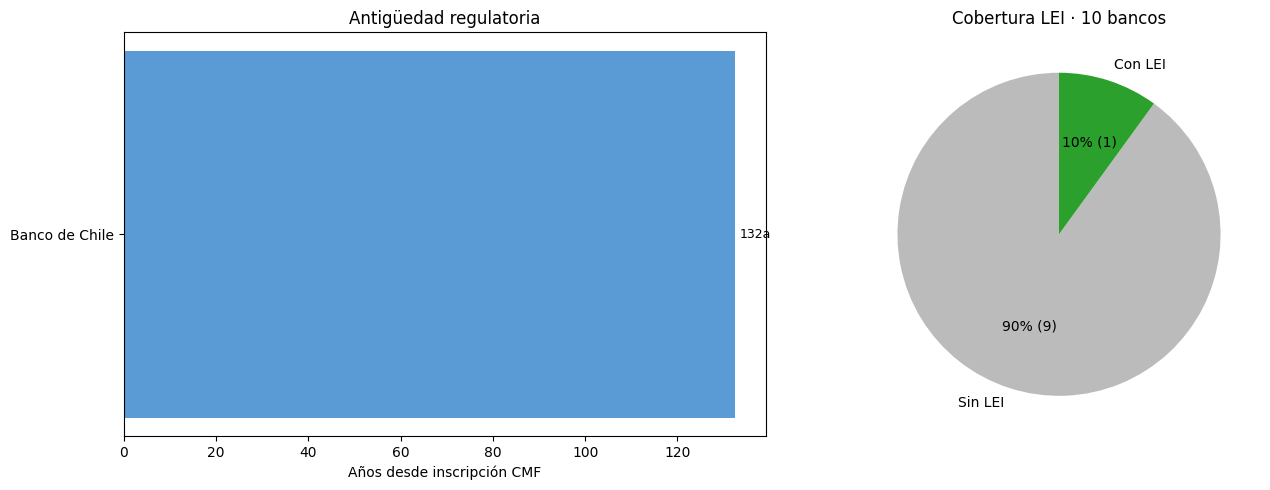

Bancos con LEI registrado en el backend:
  Banco de Chile             PVVK4N5A7MITLWQJQQ35


In [5]:
ordered2 = df.sort_values("age_years", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Antigüedad
axes[0].barh(ordered2["hint"], ordered2["age_years"], color="#5b9bd5")
for i, (n, age) in enumerate(zip(ordered2["hint"], ordered2["age_years"])):
    axes[0].text(age + 1, i, f"{age:.0f}a", va="center", fontsize=9)
axes[0].set_xlabel("Años desde inscripción CMF")
axes[0].set_title("Antigüedad regulatoria")

# (b) LEI presence
df["has_lei"] = df["lei"].notna()
counts = df["has_lei"].value_counts()
labels = ["Con LEI" if k else "Sin LEI" for k in counts.index]
colors = ["#2ca02c" if k else "#bbbbbb" for k in counts.index]
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct=lambda p: f"{p:.0f}% ({int(p*sum(counts.values)/100)})", startangle=90)
axes[1].set_title("Cobertura LEI · 10 bancos")

plt.tight_layout(); plt.show()

with_lei = df[df["has_lei"]][["hint", "lei"]]
print("Bancos con LEI registrado en el backend:")
for _, row in with_lei.iterrows():
    print(f"  {row['hint']:25s}  {row['lei']}")


## 6 · Verificación: grafo de ownership GLEIF Level-2

Como cross-check del gap de LEI, llamamos `entities.ownership(entity_id)`
para cada banco. El endpoint devuelve el grafo Level-2 de GLEIF (LEI propio,
direct parent, ultimate parent). Si el LEI propio está vacío, el grafo
está vacío también — confirmando que es un gap de ingestión, no del SDK.


In [6]:
async def fetch_ownership(c, item):
    rut, hint = item
    try:
        ent = await c.entities.by_rut(rut)
        eid = ent["id"]
        own = await c.entities.ownership(eid)
        return {"hint": hint, "rut": rut, "entity_id": eid, "ownership": own}
    except Exception as e:
        return {"hint": hint, "rut": rut, "entity_id": None, "err": str(e)[:100]}

ownerships = asyncio.run(gather_throttled(fetch_ownership, BANKS, concurrency=5))

own_rows = []
for o in ownerships:
    own = o.get("ownership") or {}
    own_rows.append({
        "banco": o["hint"],
        "subject_lei": (own.get("subject_lei") or {}).get("lei") if isinstance(own.get("subject_lei"), dict) else own.get("subject_lei"),
        "direct_parent": bool(own.get("direct_parent")),
        "ultimate_parent": bool(own.get("ultimate_parent")),
        "graph_present": bool(own.get("subject_lei") or own.get("direct_parent")),
    })
pd.DataFrame(own_rows)


,banco,subject_lei,direct_parent,ultimate_parent,graph_present
0,BancoEstado,NaN,False,False,False
1,Banco de Chile,PVVK4N5A7MITLWQJQQ35,False,False,True
2,Banco Santander Chile,NaN,False,False,False
3,BCI,NaN,False,False,False
4,Scotiabank Chile,NaN,False,False,False
5,Itaú Chile,NaN,False,False,False
6,Banco BICE,NaN,False,False,False
7,Banco Falabella,NaN,False,False,False
8,Banco Consorcio,NaN,False,False,False
9,Banco Security,NaN,False,False,False


## 7 · Composición de directorios

Tamaño del directorio actual desde `kyb.get(include=['directors'])`. El
ingestor `cmf_directores_gerentes.py` parsea las publicaciones mensuales
de la CMF — **la cobertura varía por banco** dependiendo de cuántos
ciclos haya completado el ingestor.


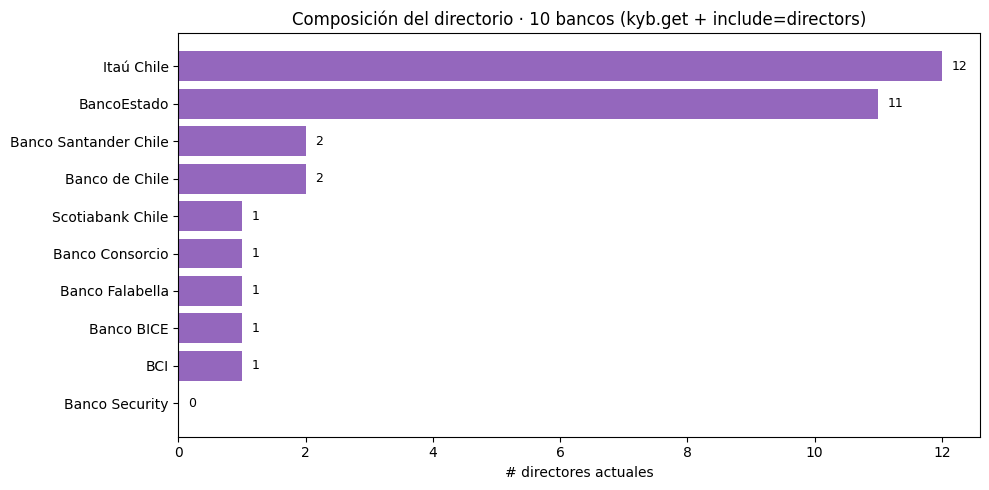


Total directores listados: 32

Top cargos:
cargo
director           21
gerente_general     8
presidente          3


In [7]:
ordered3 = df.sort_values("n_directors")
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(ordered3["hint"], ordered3["n_directors"], color="#9467bd")
for b, n in zip(bars, ordered3["n_directors"]):
    ax.text(n + 0.15, b.get_y() + b.get_height()/2, f"{n}", va="center", fontsize=9)
ax.set_xlabel("# directores actuales")
ax.set_title("Composición del directorio · 10 bancos (kyb.get + include=directors)")
plt.tight_layout(); plt.show()

all_dirs = []
for p in profiles:
    for d in p["_directors"]:
        all_dirs.append({"banco": p["hint"], "cargo": d.get("cargo"),
                         "nombre": d.get("nombre"), "rut": d.get("persona_rut")})
df_dirs = pd.DataFrame(all_dirs)
print(f"\nTotal directores listados: {len(df_dirs)}")
if len(df_dirs):
    print(f"\nTop cargos:")
    print(df_dirs["cargo"].value_counts().head(8).to_string())


## 8 · Bancos · fichas regulatorias (CMF SBIF)

`entities.bancos_fichas_latest_per_section(rut)` une los reportes
mensuales SBIF que la CMF publica para cada banco. Secciones:

- **`accionistas`** — composición accionaria mensual
- **`adecuacion_capital`** — Basel III (capital básico, RWA, bonos subordinados)
- **`integrantes`** — gerente general + plana ejecutiva
- **`perfil`** — sucursales, cajeros, empleados


In [8]:
async def fetch_fichas(c, item):
    rut, hint = item
    try:
        body = await c.entities.bancos_fichas_latest_per_section(rut)
        return {"hint": hint, "rut": rut, "sections": body.get("sections", []), "ok": True}
    except Exception as e:
        return {"hint": hint, "rut": rut, "sections": [], "ok": False, "err": str(e)[:120]}

fichas = asyncio.run(gather_throttled(fetch_fichas, BANKS, concurrency=5))

# Cobertura de secciones por banco
section_matrix = []
for f in fichas:
    sections = {s["section"]: f"FY{s.get('fiscal_year')}-M{s.get('fiscal_month'):02d}"
                for s in f["sections"] if s.get('fiscal_month')}
    section_matrix.append({"banco": f["hint"], **sections})
df_cov = pd.DataFrame(section_matrix).set_index("banco").fillna("—")
print(f"Bancos con fichas exitosas: {sum(1 for f in fichas if f['ok'])}/10")
df_cov


Bancos con fichas exitosas: 9/10


,adecuacion_capital,integrantes,perfil,accionistas
banco,,,,
BancoEstado,FY2020-M11,FY2026-M04,FY2026-M04,—
Banco de Chile,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Banco Santander Chile,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
BCI,FY2020-M10,FY2026-M04,FY2026-M04,FY2026-M04
Scotiabank Chile,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Itaú Chile,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Banco BICE,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Banco Falabella,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Banco Consorcio,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04


## 9 · Footprint físico (sucursales · cajeros · empleados)

In [9]:
def _extract_perfil(f):
    for s in f.get("sections", []):
        if s["section"] == "perfil":
            perfiles = (s.get("payload") or {}).get("Perfiles") or []
            if perfiles:
                return perfiles[0].get("Perfil") or {}
    return {}

perfil_rows = []
for f in fichas:
    p = _extract_perfil(f)
    if p:
        perfil_rows.append({
            "banco": f["hint"],
            "sucursales": p.get("sucursales") or 0,
            "oficinas": p.get("oficinas") or 0,
            "cajeros": p.get("cajeros") or 0,
            "empleados": p.get("empleados") or 0,
            "swift": p.get("codigoSWIFT") or "—",
            "web": p.get("direccionWeb") or "—",
        })

df_perfil = pd.DataFrame(perfil_rows).sort_values("empleados", ascending=False)
print(f"Bancos con perfil físico disponible: {len(df_perfil)}/10")
print()
print(df_perfil[["banco","sucursales","cajeros","empleados","swift"]].to_string(index=False))


Bancos con perfil físico disponible: 9/10

                banco  sucursales  cajeros  empleados      swift
          BancoEstado         426     2554      10711 BECH CL RM
       Banco de Chile         211     1881      10297 BCHI CL RM
Banco Santander Chile         158     2064       8002 BSCH CL RM
                  BCI         168      548       7439 CRED CL RM
     Scotiabank Chile          92      153       5118 BKSA CL RM
           Itaú Chile          94      140       4484   ITAUCLRM
           Banco BICE          40       36       2854 BICE CL RM
      Banco Falabella          71      366       2071 FALA CL RM
      Banco Consorcio          16       12       1064 MNEX CL RM


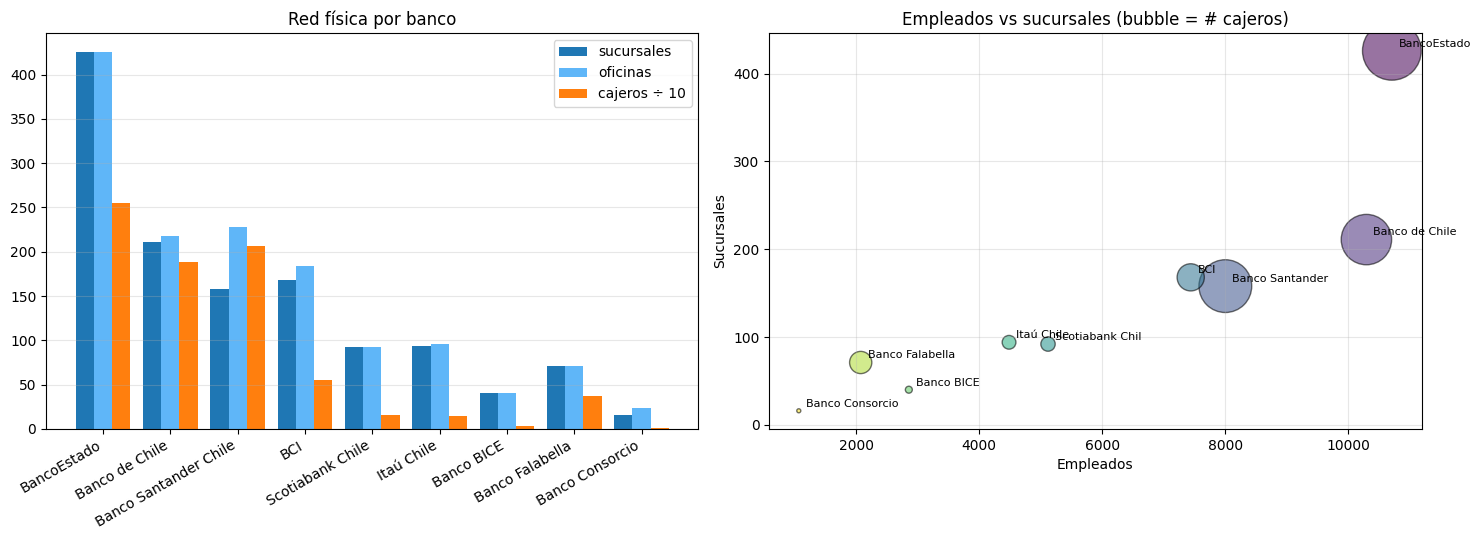

In [10]:
if len(df_perfil) >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    # (a) Barras agrupadas
    ax = axes[0]
    x = list(range(len(df_perfil)))
    width = 0.27
    ax.bar([i - width for i in x], df_perfil["sucursales"], width, label="sucursales", color="#1f77b4")
    ax.bar(x, df_perfil["oficinas"], width, label="oficinas", color="#5fb6f8")
    ax.bar([i + width for i in x], df_perfil["cajeros"]/10, width, label="cajeros ÷ 10", color="#ff7f0e")
    ax.set_xticks(x)
    ax.set_xticklabels(df_perfil["banco"], rotation=30, ha="right")
    ax.set_title("Red física por banco")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    # (b) Bubble — área proporcional a # cajeros
    ax = axes[1]
    sizes = df_perfil["cajeros"].fillna(0).clip(lower=10) * 0.7
    ax.scatter(df_perfil["empleados"], df_perfil["sucursales"], s=sizes, alpha=0.55,
               c=range(len(df_perfil)), cmap="viridis", edgecolor="black")
    for _, row in df_perfil.iterrows():
        ax.annotate(row["banco"][:15], (row["empleados"], row["sucursales"]),
                    fontsize=8, xytext=(5, 3), textcoords="offset points")
    ax.set_xlabel("Empleados")
    ax.set_ylabel("Sucursales")
    ax.set_title("Empleados vs sucursales (bubble = # cajeros)")
    ax.grid(alpha=0.3)

    plt.tight_layout(); plt.show()


## 10 · Adecuación de capital (Basel III) — RWA y patrimonio

La sección `adecuacion_capital` trae mensualmente: activos totales,
activos ponderados por riesgo (RWA), patrimonio efectivo, capital básico,
bonos subordinados. Calculamos el **Tier 1 ratio** (capital básico / RWA)
y el **total capital ratio** (patrimonio efectivo / RWA).

> ⚠️ **Nota sobre vigencia**: el dato más reciente disponible para muchas
> fichas es de **2020-11** — es lo último que el ingestor tiene cargado.
> En producción, el backend correría el ingestor mensualmente.


In [11]:
def _to_float(s):
    """Los valores vienen con coma decimal española — '47485336,642804'."""
    if s is None or s == "":
        return None
    if isinstance(s, (int, float)):
        return float(s)
    return float(str(s).replace(".", "").replace(",", "."))

def _extract_capital(f):
    for s in f.get("sections", []):
        if s["section"] == "adecuacion_capital":
            arr = (s.get("payload") or {}).get("AdecuacionDeCapital") or []
            if arr:
                comp = (arr[0].get("Componentes") or {})
                act = comp.get("Activos") or {}
                pat = comp.get("PatrimonioEfectivo") or {}
                return {
                    "as_of": f"{s.get('fiscal_year')}-{s.get('fiscal_month'):02d}",
                    "activos_totales": _to_float(act.get("Totales")),
                    "rwa": _to_float(act.get("PonderadosPorRiesgo")),
                    "patrimonio_total": _to_float(pat.get("Total")),
                    "capital_basico": _to_float(pat.get("CapitalBasico")),
                    "bonos_subordinados": _to_float(pat.get("BonosSubordinados")),
                }
    return None

cap_rows = []
for f in fichas:
    cap = _extract_capital(f)
    if cap:
        cap["banco"] = f["hint"]
        cap["tier1_pct"]  = (cap["capital_basico"] / cap["rwa"] * 100) if cap["rwa"] else None
        cap["total_pct"]  = (cap["patrimonio_total"] / cap["rwa"] * 100) if cap["rwa"] else None
        cap_rows.append(cap)

df_cap = pd.DataFrame(cap_rows).sort_values("total_pct", ascending=True)
print(f"Bancos con adecuación de capital disponible: {len(df_cap)}/10")
df_cap[["banco","as_of","activos_totales","rwa","capital_basico","patrimonio_total","tier1_pct","total_pct"]]


Bancos con adecuación de capital disponible: 9/10


,banco,as_of,activos_totales,rwa,capital_basico,patrimonio_total,tier1_pct,total_pct
0,BancoEstado,2020-11,4.974778e+07,2.493909e+07,2.012257e+06,3.158270e+06,8.068686,12.663933
4,Scotiabank Chile,2020-11,3.521686e+07,2.483721e+07,2.377898e+06,3.195704e+06,9.573932,12.866597
3,BCI,2020-10,5.700937e+07,3.861257e+07,3.938828e+06,4.982904e+06,10.200895,12.904873
5,Itaú Chile,2020-11,3.590571e+07,2.343724e+07,2.358248e+06,3.104306e+06,10.061970,13.245184
6,Banco BICE,2020-11,9.597613e+06,6.729136e+06,6.495415e+05,8.960638e+05,9.652673,13.316179
2,Banco Santander Chile,2020-11,5.266018e+07,3.437209e+07,3.489817e+06,5.037503e+06,10.153054,14.655796
1,Banco de Chile,2020-11,4.748534e+07,3.110592e+07,3.722925e+06,4.854002e+06,11.968542,15.604755
8,Banco Consorcio,2020-11,6.242243e+06,4.675667e+06,5.810867e+05,8.263901e+05,12.427888,17.674273
7,Banco Falabella,2020-11,6.312691e+06,4.280707e+06,6.358385e+05,8.222708e+05,14.853588,19.208763


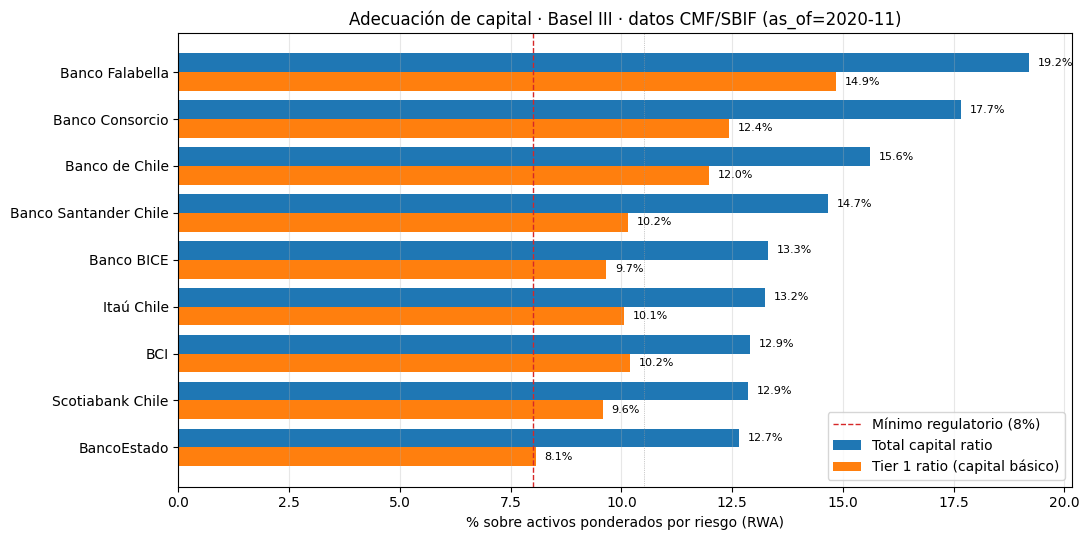


Tier 1 promedio (banca chilena big-9): 10.77%
Total capital ratio promedio:              14.68%


In [12]:
if len(df_cap) >= 3:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    y = list(range(len(df_cap)))
    ax.barh([i + 0.2 for i in y], df_cap["total_pct"], 0.4, label="Total capital ratio", color="#1f77b4")
    ax.barh([i - 0.2 for i in y], df_cap["tier1_pct"],  0.4, label="Tier 1 ratio (capital básico)", color="#ff7f0e")
    for i, (t1, tot) in enumerate(zip(df_cap["tier1_pct"], df_cap["total_pct"])):
        ax.text(tot + 0.2, i + 0.2, f"{tot:.1f}%", va="center", fontsize=8)
        ax.text(t1 + 0.2,  i - 0.2, f"{t1:.1f}%",  va="center", fontsize=8)
    ax.axvline(8.0, color="#d62728", lw=1, ls="--", label="Mínimo regulatorio (8%)")
    ax.axvline(10.5, color="#999", lw=0.5, ls=":")
    ax.set_yticks(y)
    ax.set_yticklabels(df_cap["banco"])
    ax.set_xlabel("% sobre activos ponderados por riesgo (RWA)")
    ax.set_title(f"Adecuación de capital · Basel III · datos CMF/SBIF (as_of={df_cap['as_of'].mode().iloc[0]})")
    ax.legend()
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f"\nTier 1 promedio (banca chilena big-{len(df_cap)}): {df_cap['tier1_pct'].mean():.2f}%")
    print(f"Total capital ratio promedio:              {df_cap['total_pct'].mean():.2f}%")


## 11 · Top accionistas — concentración de propiedad

Para cada banco extraemos los 5 mayores accionistas (filtrando filas
agregadoras como `TOTAL`, `SUBTOTAL`, `OTROS ACCIONISTAS` que el feed
SBIF inserta para totalizar — no son shareholders reales).


In [13]:
_AGGREGATOR_NAMES = {
    "TOTAL", "SUBTOTAL",
    "12 ACCIONISTAS MAYORITARIOS",
    "RESTO ACCIONISTAS", "OTROS ACCIONISTAS",
}

def _is_aggregator(name: str) -> bool:
    n = (name or "").strip().upper()
    if not n: return True
    if n in _AGGREGATOR_NAMES: return True
    if n.startswith("OTROS ") or n.startswith("RESTO "): return True
    if "ACCIONISTAS" in n and ("MAYORIT" in n or "MINORIT" in n): return True
    return False

def _extract_accionistas(f, top=5):
    for s in f.get("sections", []):
        if s["section"] == "accionistas":
            arr = (s.get("payload") or {}).get("Accionistas") or []
            rows = []
            for a in arr:
                d = a.get("DescripcionAccionista") or {}
                nombre = d.get("Nombre", "")
                if _is_aggregator(nombre): continue
                rows.append({
                    "rut": d.get("Rut"),
                    "nombre": nombre,
                    "participacion": float(d.get("Participacion") or 0),
                    "n_acciones": int(d.get("NumeroAcciones") or 0),
                })
            rows.sort(key=lambda r: r["participacion"], reverse=True)
            return rows[:top]
    return []

acc_rows = []
for f in fichas:
    for a in _extract_accionistas(f, top=5):
        acc_rows.append({"banco": f["hint"], **a})

df_acc = pd.DataFrame(acc_rows)
print(f"Bancos con accionistas en ficha: {df_acc['banco'].nunique() if len(df_acc) else 0}/10")
print(f"Total accionistas extraídos (top-5 × bancos):  {len(df_acc)}")

if len(df_acc):
    print("\nTop accionista por banco:")
    top1 = df_acc.sort_values("participacion", ascending=False).drop_duplicates("banco")
    top1 = top1.sort_values("participacion", ascending=False)
    for _, r in top1.iterrows():
        print(f"  {r['banco']:25s}  {r['nombre'][:42]:42s}  {r['participacion']:>6.2f}%")


Bancos con accionistas en ficha: 8/10
Total accionistas extraídos (top-5 × bancos):  34

Top accionista por banco:
  Banco Falabella            FALABELLA INV FINANCIERAS S.A.              100.00%
  Banco Consorcio            CONSOR FINANCIERO S.A.                       99.99%
  Banco BICE                 BICECORP S.A.                                99.94%
  Scotiabank Chile           NOVA SCOTIA INV LTDA                         99.80%
  BCI                        EMP JUAN YARUR S.A.C.                        55.36%
  Banco de Chile             LQ INV FINANCIERAS S.A.                      46.34%
  Itaú Chile                 ITB HOLDING BRASIL PARTICIPACOES             36.42%
  Banco Santander Chile      SANTANDER CHILE HOLDING S.A.                 35.46%


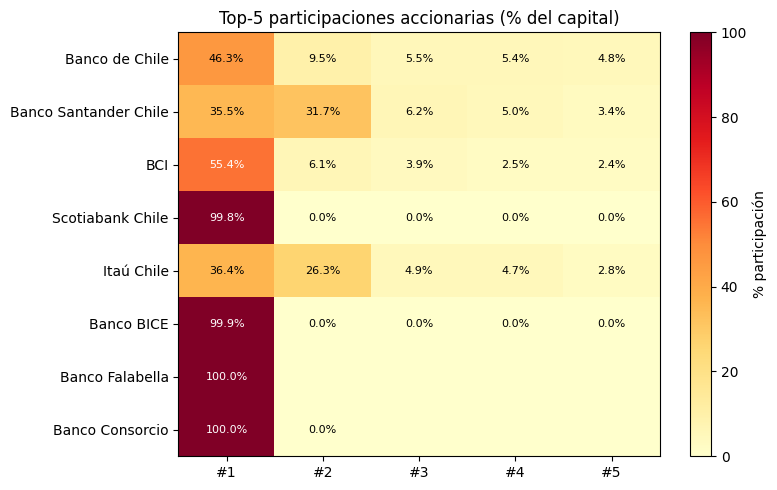

In [14]:
if len(df_acc) >= 3:
    banks_with_acc = df_acc["banco"].unique()
    heat_rows = []
    for b in banks_with_acc:
        top5 = df_acc[df_acc["banco"] == b].nlargest(5, "participacion")["participacion"].tolist()
        while len(top5) < 5:
            top5.append(0)
        heat_rows.append((b, top5))

    heat = pd.DataFrame([r[1] for r in heat_rows], index=[r[0] for r in heat_rows],
                        columns=[f"#{i}" for i in range(1, 6)])

    fig, ax = plt.subplots(figsize=(8, max(3, 0.5*len(heat) + 1)))
    im = ax.imshow(heat.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=heat.values.max())
    ax.set_xticks(range(5)); ax.set_xticklabels(heat.columns)
    ax.set_yticks(range(len(heat))); ax.set_yticklabels(heat.index)
    for i in range(len(heat)):
        for j in range(5):
            v = heat.iloc[i, j]
            if v > 0:
                ax.text(j, i, f"{v:.1f}%", ha="center", va="center",
                        color="white" if v > heat.values.max() * 0.5 else "black", fontsize=8)
    ax.set_title("Top-5 participaciones accionarias (% del capital)")
    fig.colorbar(im, ax=ax, label="% participación")
    plt.tight_layout(); plt.show()


## 12 · Sanciones CMF · uno por uno

`entities.by_rut(rut) → entity_id` y luego `entities.sanctions(entity_id)`.
Async + throttled.


In [15]:
async def fetch_sanctions(c, item):
    rut, hint = item
    try:
        ent = await c.entities.by_rut(rut)
        eid = ent["id"]
        sancs = await c.entities.sanctions(eid)
        return {"hint": hint, "rut": rut, "entity_id": eid, "sanctions": sancs}
    except Exception as e:
        return {"hint": hint, "rut": rut, "sanctions": [], "err": str(e)[:120]}

bank_sancs = asyncio.run(gather_throttled(fetch_sanctions, BANKS, concurrency=5))

sanc_rows = []
for bs in bank_sancs:
    for s in bs["sanctions"]:
        sanc_rows.append({
            "banco": bs["hint"],
            "id": s.get("cmf_resolucion_id"),
            "fecha": s.get("fecha_resolucion"),
            "estado": s.get("estado"),
            "multa_uf": s.get("multa_uf"),
            "infraccion": (s.get("infraccion") or "")[:80],
        })
df_sanc = pd.DataFrame(sanc_rows)
df_sanc["fecha"] = pd.to_datetime(df_sanc["fecha"], errors="coerce")
df_sanc["multa_uf_num"] = pd.to_numeric(df_sanc["multa_uf"], errors="coerce")

print(f"Total sanciones recolectadas (10 bancos): {len(df_sanc)}")
if len(df_sanc):
    print(f"Fechas: {df_sanc['fecha'].min().date()} → {df_sanc['fecha'].max().date()}")
    print(f"Multas UF totales: {df_sanc['multa_uf_num'].sum():,.0f}")
    print(f"\nDistribución por estado:")
    print(df_sanc["estado"].value_counts().to_string())


Total sanciones recolectadas (10 bancos): 43
Fechas: 2020-05-28 → 2026-02-09
Multas UF totales: 398

Distribución por estado:
estado
prescrita    39
vigente       4


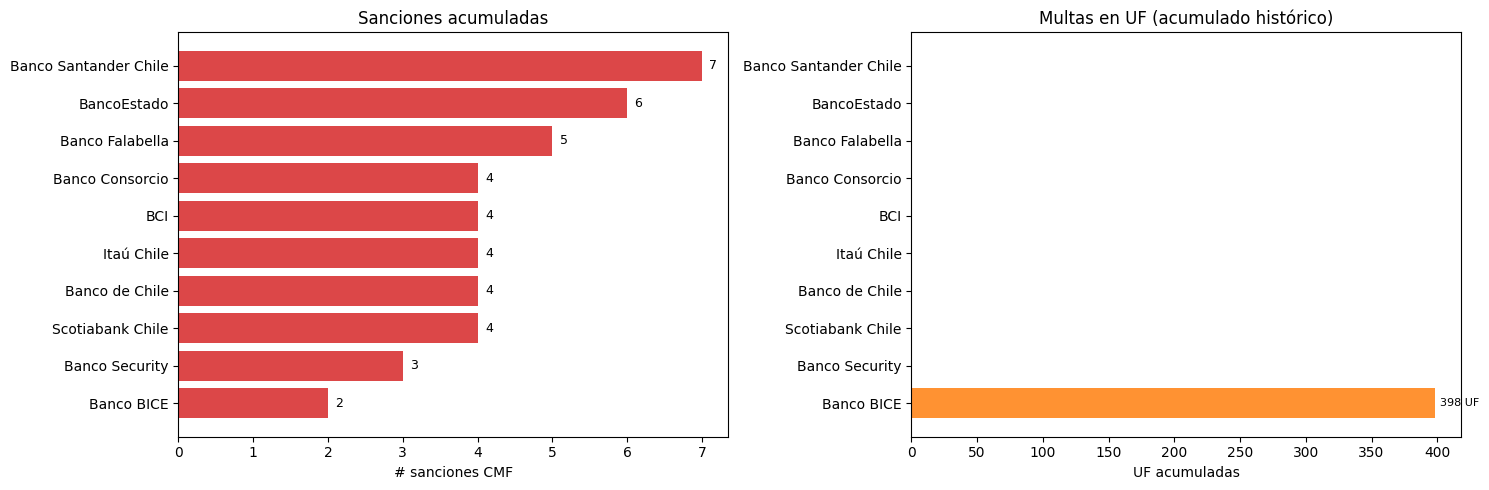

In [16]:
# Conteo + UF totales por banco
agg = df_sanc.groupby("banco").agg(
    n_sanciones=("id", "count"),
    total_uf=("multa_uf_num", lambda s: s.sum()),
).reset_index()
all_banks = pd.DataFrame({"banco": [h for _, h in BANKS]})
agg = all_banks.merge(agg, on="banco", how="left").fillna(0).sort_values("n_sanciones")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(agg["banco"], agg["n_sanciones"], color="#d62728", alpha=0.85)
for i, n in enumerate(agg["n_sanciones"]):
    axes[0].text(n + 0.1, i, f"{int(n)}", va="center", fontsize=9)
axes[0].set_xlabel("# sanciones CMF")
axes[0].set_title("Sanciones acumuladas")

axes[1].barh(agg["banco"], agg["total_uf"], color="#ff7f0e", alpha=0.85)
for i, n in enumerate(agg["total_uf"]):
    if n > 0:
        axes[1].text(n + agg["total_uf"].max()*0.01, i, f"{int(n):,} UF", va="center", fontsize=8)
axes[1].set_xlabel("UF acumuladas")
axes[1].set_title("Multas en UF (acumulado histórico)")

plt.tight_layout(); plt.show()


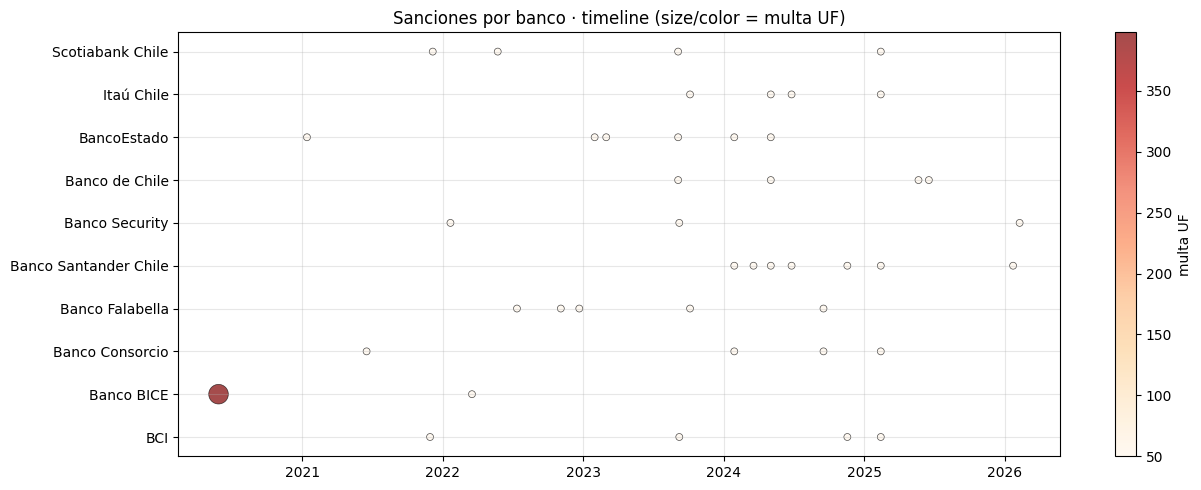

In [17]:
# Timeline scatter — fecha × banco, tamaño = multa UF
df_t = df_sanc.dropna(subset=["fecha"]).copy()
if len(df_t):
    df_t["multa_uf_num_filled"] = df_t["multa_uf_num"].fillna(50)
    bank_order = sorted(df_t["banco"].unique())
    bank_to_y = {b: i for i, b in enumerate(bank_order)}
    df_t["y"] = df_t["banco"].map(bank_to_y)

    fig, ax = plt.subplots(figsize=(13, 5))
    sc = ax.scatter(df_t["fecha"], df_t["y"],
                    s=df_t["multa_uf_num_filled"].clip(50, 5000) * 0.5,
                    c=df_t["multa_uf_num_filled"], cmap="OrRd", alpha=0.7,
                    edgecolor="black", linewidth=0.5)
    ax.set_yticks(list(bank_to_y.values()))
    ax.set_yticklabels(list(bank_to_y.keys()))
    ax.set_title("Sanciones por banco · timeline (size/color = multa UF)")
    fig.colorbar(sc, ax=ax, label="multa UF")
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


## 13 · Cross-reference contra listas internacionales

`sanctions.cross_reference(name=…)` matchea contra OFAC SDN, UN
Consolidated, EU/UK y CMF interno. Threshold bajo (0.6) para detectar
nombres similares.

> ⚠️ **Importante**: este endpoint es CPU-bound (fuzzy match con
> embeddings contra 4 listas de 10K-100K registros cada una). Por eso
> usamos `concurrency=3` para evitar back-pressure (que causaría retries
> y 500s en lanzamiento simultáneo de 10).


In [18]:
async def fetch_xref(c, item):
    rut, hint = item
    legal_name = next(p["legal_name"] for p in profiles if p["rut"] == rut)
    try:
        cr = await c.sanctions.cross_reference(name=legal_name, threshold=0.6, limit=10)
        return {"hint": hint, "matches": cr.get("matches", [])}
    except Exception as e:
        return {"hint": hint, "matches": [], "err": str(e)[:120]}

# concurrency=3: el endpoint es expensive. 3 es el sweet spot empírico.
xrefs = asyncio.run(gather_throttled(fetch_xref, BANKS, concurrency=3))

xref_rows = []
for x in xrefs:
    for m in x["matches"]:
        xref_rows.append({
            "banco": x["hint"],
            "source": m.get("source"),
            "matched_name": m.get("name"),
            "score": m.get("score"),
            "programs": "; ".join(m.get("programs") or []),
        })
df_xr = pd.DataFrame(xref_rows)
print(f"Total matches: {len(df_xr)}")
errs = [x for x in xrefs if x.get("err")]
if errs:
    print(f"Errores: {len(errs)}  (primero: {errs[0]['err']})")
if len(df_xr):
    print(f"\nPor fuente:")
    print(df_xr["source"].value_counts().to_string())


Total matches: 100

Por fuente:
source
ofac_sdn    91
cmf          9


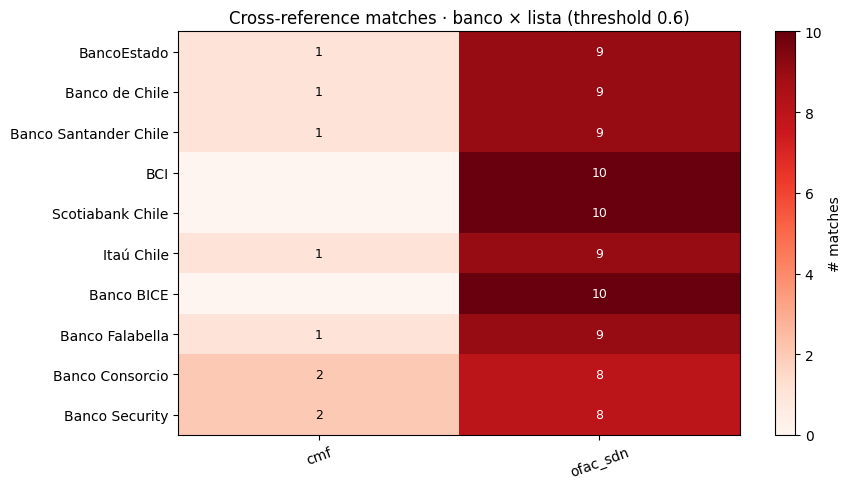


Top-10 matches absolutos:
                banco   source                                                                              matched_name  score                        programs
Banco Santander Chile      cmf                                                                     BANCO SANTANDER CHILE 0.9810                                
           Banco BICE ofac_sdn                                       BANCO DE DESARROLLO ECONOMICO Y SOCIAL DE VENEZUELA 0.8933               VENEZUELA-EO13850
Banco Santander Chile ofac_sdn                                                                      BANCO CORPORATIVO SA 0.8788                       NICARAGUA
       Banco de Chile      cmf                                                                     BANCO SANTANDER CHILE 0.8781                                
           Banco BICE ofac_sdn                                                                       BANCO VTB AFRICA SA 0.8747 UKRAINE-EO13662; RUSSIA-EO14024
      Banco C

In [19]:
if len(df_xr):
    pivot = df_xr.groupby(["banco", "source"]).size().unstack(fill_value=0)
    pivot = pivot.reindex([h for _, h in BANKS]).fillna(0).astype(int)
    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.imshow(pivot.values, cmap="Reds", aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=20)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.iloc[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center",
                        color="white" if v > pivot.values.max() * 0.5 else "black", fontsize=9)
    ax.set_title("Cross-reference matches · banco × lista (threshold 0.6)")
    fig.colorbar(im, ax=ax, label="# matches")
    plt.tight_layout(); plt.show()

    print("\nTop-10 matches absolutos:")
    top10 = df_xr.nlargest(10, "score")[["banco","source","matched_name","score","programs"]]
    print(top10.to_string(index=False))


## 14 · Búsqueda semántica · queries específicos de banca

In [20]:
QUERIES = [
    "Basel III adecuación capital banca chilena",
    "incumplimiento prevención lavado activos UAF",
    "ciberseguridad resiliencia operacional bancos",
]

with CerberusClient() as c:
    rows = []
    for q in QUERIES:
        resp = c.search.search(query=q, top_k=5)
        for h in resp.hits:
            rows.append({
                "query": q[:35] + "…" if len(q) > 35 else q,
                "score": h.score,
                "source": h.source_table,
                "tipo": h.tipo_documento,
                "rut": h.entity_rut or "—",
            })

df_search = pd.DataFrame(rows)
df_search.head(20)


,query,score,source,tipo,rut
0,Basel III adecuación capital banca …,0.432544,cmf_resoluciones,otro,—
1,Basel III adecuación capital banca …,0.388912,cmf_art12_transactions,art12_transaccion,—
2,Basel III adecuación capital banca …,0.382737,cmf_art12_transactions,art12_transaccion,—
3,Basel III adecuación capital banca …,0.373237,cmf_opas,opa,—
4,Basel III adecuación capital banca …,0.359553,cmf_opas,opa,—
5,incumplimiento prevención lavado ac…,0.342572,cmf_ran_capitulos,ran_capitulo,—
6,incumplimiento prevención lavado ac…,0.274794,cmf_comunicaciones,comunicacion_respuesta_oficio,—
7,incumplimiento prevención lavado ac…,0.253072,cmf_hechos_esenciales,hecho_esencial,—
8,incumplimiento prevención lavado ac…,0.246510,cmf_comunicaciones,comunicacion_voluntaria,—
9,incumplimiento prevención lavado ac…,0.243654,cmf_comunicaciones,comunicacion_respuesta_oficio,—


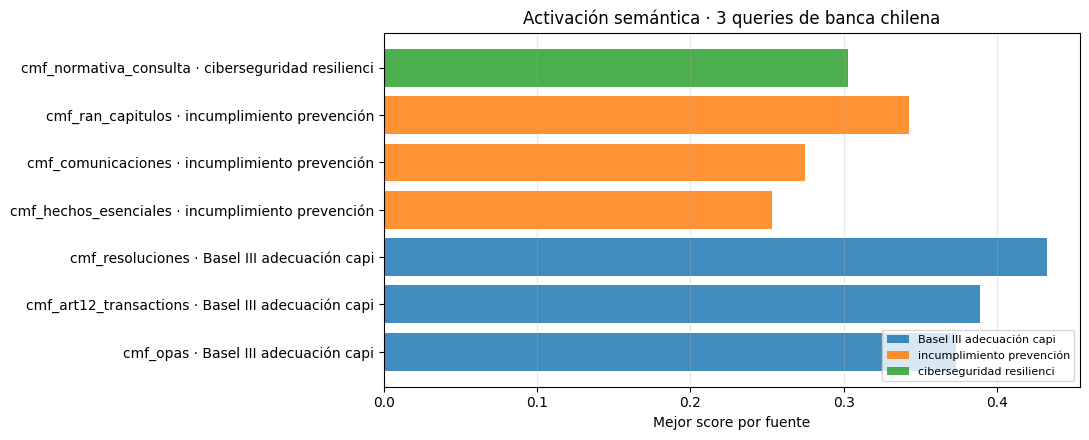

In [21]:
# Activación por tabla a través de los 3 queries
fig, ax = plt.subplots(figsize=(11, 4.5))
for q, color in zip(df_search["query"].unique(), ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    sub = df_search[df_search["query"] == q]
    by_src = sub.groupby("source")["score"].max().sort_values(ascending=True)
    ax.barh([f"{s} · {q[:25]}" for s in by_src.index], by_src.values, color=color, alpha=0.85, label=q[:25])
ax.set_xlabel("Mejor score por fuente")
ax.set_title("Activación semántica · 3 queries de banca chilena")
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()


## 15 · Telón macro · UF · USD · TPM · IPC (12m)

Puntos por serie:
  UF   :  366 puntos
  USD  :  249 puntos
  TPM  :  249 puntos
  IPC  :   11 puntos


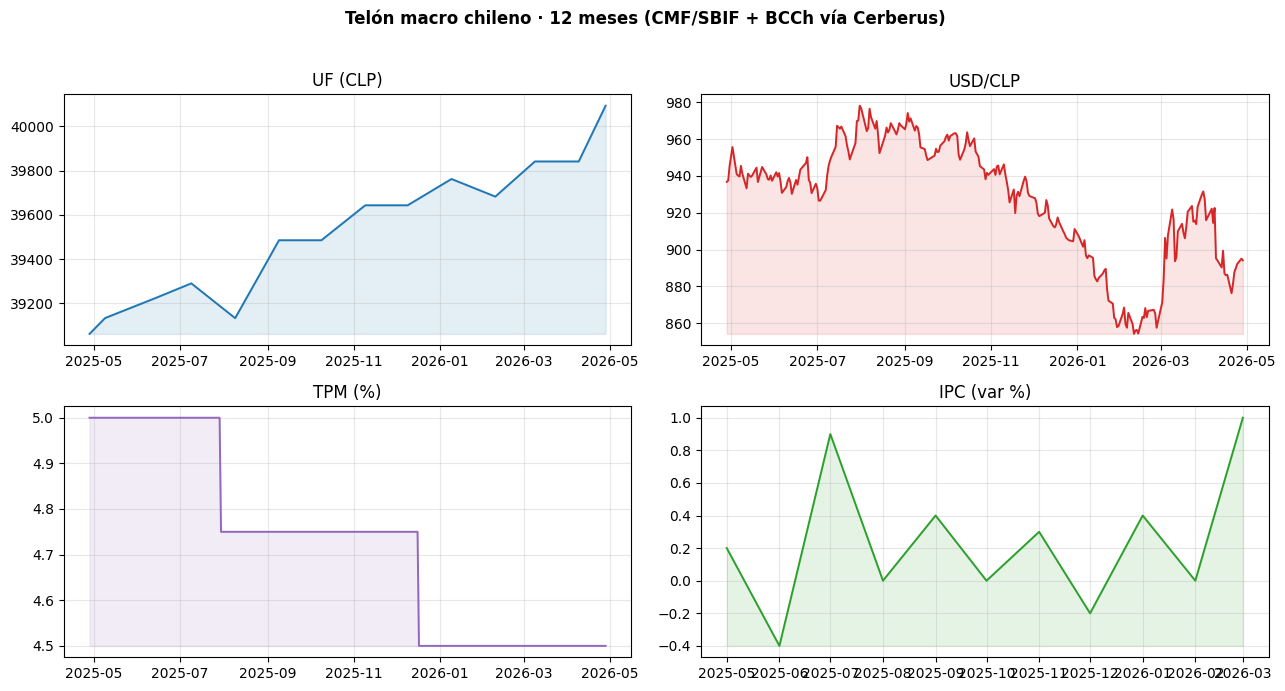

In [22]:
today = date.today()
start = (today - timedelta(days=365)).isoformat()
end   = today.isoformat()

with CerberusClient() as c:
    series = {
        "UF":  c.indicadores.history("UF",  from_=start, to=end),
        "USD": c.indicadores.history("USD", from_=start, to=end),
        "TPM": c.indicadores.history("TPM", from_=start, to=end),
        "IPC": c.indicadores.history("IPC", from_=start, to=end),
    }

print("Puntos por serie:")
for k, v in series.items():
    print(f"  {k:5s}: {len(v):>4} puntos")

def _df(s):
    if not s: return pd.DataFrame(columns=["date","value"])
    return pd.DataFrame(s).assign(date=lambda d: pd.to_datetime(d["date"]),
                                   value=lambda d: pd.to_numeric(d["value"]))

df_uf, df_usd, df_tpm, df_ipc = _df(series["UF"]), _df(series["USD"]), _df(series["TPM"]), _df(series["IPC"])

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Telón macro chileno · 12 meses (CMF/SBIF + BCCh vía Cerberus)", fontsize=12, weight="bold")
for ax, (df_, lbl, color) in zip(axes.flat,
    [(df_uf, "UF (CLP)", "#1f77b4"), (df_usd, "USD/CLP", "#d62728"),
     (df_tpm, "TPM (%)", "#9467bd"), (df_ipc, "IPC (var %)", "#2ca02c")]):
    if len(df_):
        ax.plot(df_["date"], df_["value"], color=color, lw=1.4)
        ax.fill_between(df_["date"], df_["value"].min(), df_["value"], alpha=0.12, color=color)
        ax.set_title(lbl)
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, f"{lbl}\n(sin datos en este período)", ha="center", va="center", transform=ax.transAxes)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


## 16 · Matriz de cobertura · qué endpoint pobló qué banco

Honest by design: este resumen muestra **dónde el backend tiene datos
y dónde no**, para que cualquier consumidor del SDK calibre sus
expectativas. Los gaps son del lado de los ingestores async, no del SDK.


In [23]:
coverage = []
for rut, hint in BANKS:
    profile = next(p for p in profiles if p["rut"] == rut)
    f = next(f for f in fichas if f["rut"] == rut)
    o = next(x for x in ownerships if x["rut"] == rut)
    bs = next(b for b in bank_sancs if b["rut"] == rut)

    has_perfil = bool(_extract_perfil(f))
    has_capital = bool(_extract_capital(f))
    has_acc = bool(_extract_accionistas(f, top=1))
    has_int = any(s["section"] == "integrantes" for s in f.get("sections", []))
    has_lei_own = bool(o.get("ownership", {}).get("subject_lei") if isinstance(o.get("ownership"), dict) else False)

    coverage.append({
        "banco": hint,
        "kyb": "✓",
        "directors": "✓" if profile["n_directors"] > 0 else "—",
        "lei": "✓" if profile["lei"] else "—",
        "ownership_graph": "✓" if has_lei_own else "—",
        "perfil_físico": "✓" if has_perfil else "—",
        "capital_basel": "✓" if has_capital else "—",
        "accionistas": "✓" if has_acc else "—",
        "integrantes": "✓" if has_int else "—",
        "sanciones": str(len(bs.get("sanctions", []))) if bs.get("sanctions") else "0",
    })

df_cov2 = pd.DataFrame(coverage).set_index("banco")
df_cov2


,kyb,directors,lei,ownership_graph,perfil_físico,capital_basel,accionistas,integrantes,sanciones
banco,,,,,,,,,
BancoEstado,✓,✓,—,—,✓,✓,—,✓,6
Banco de Chile,✓,✓,✓,✓,✓,✓,✓,✓,4
Banco Santander Chile,✓,✓,—,—,✓,✓,✓,✓,7
BCI,✓,✓,—,—,✓,✓,✓,✓,4
Scotiabank Chile,✓,✓,—,—,✓,✓,✓,✓,4
Itaú Chile,✓,✓,—,—,✓,✓,✓,✓,4
Banco BICE,✓,✓,—,—,✓,✓,✓,✓,2
Banco Falabella,✓,✓,—,—,✓,✓,✓,✓,5
Banco Consorcio,✓,✓,—,—,✓,✓,✓,✓,4


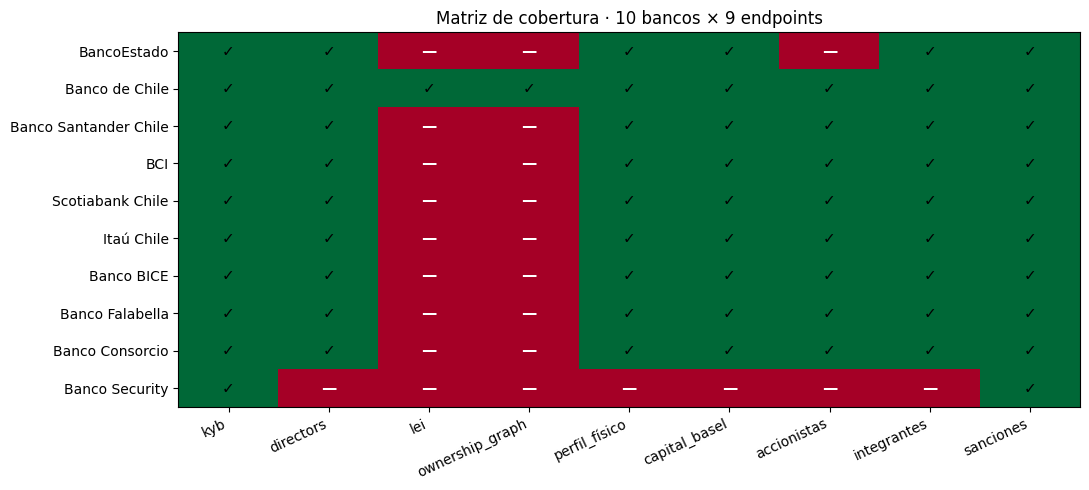


Cobertura por endpoint (% de bancos con datos):
  kyb                   100%  (10/10)
  directors              90%  (9/10)
  lei                    10%  (1/10)
  ownership_graph        10%  (1/10)
  perfil_físico          90%  (9/10)
  capital_basel          90%  (9/10)
  accionistas            80%  (8/10)
  integrantes            90%  (9/10)
  sanciones             100%  (10/10)


In [24]:
# Visualizar la matriz de cobertura como heatmap binario
def _to_bin(v):
    if v == "✓": return 1
    if v == "—": return 0
    try:
        return 1 if int(v) > 0 else 0
    except (ValueError, TypeError):
        return 0

binary = df_cov2.map(_to_bin).astype(int)

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(binary.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(binary.columns))); ax.set_xticklabels(binary.columns, rotation=25, ha="right")
ax.set_yticks(range(len(binary))); ax.set_yticklabels(binary.index)
for i in range(len(binary)):
    for j in range(len(binary.columns)):
        v = binary.iloc[i, j]
        ax.text(j, i, "✓" if v else "—", ha="center", va="center",
                color="white" if v == 0 else "black", fontsize=11, fontweight="bold")
ax.set_title("Matriz de cobertura · 10 bancos × 9 endpoints")
plt.tight_layout(); plt.show()

# Cobertura agregada
print(f"\nCobertura por endpoint (% de bancos con datos):")
for col in binary.columns:
    pct = binary[col].mean() * 100
    print(f"  {col:18s}  {pct:>5.0f}%  ({int(binary[col].sum())}/{len(binary)})")


## 17 · Dashboard ejecutivo · 9 paneles

In [25]:
master = df.set_index("hint")[["risk_score", "n_directors"]].copy()
master["age_years"] = df.set_index("hint")["age_years"]
if len(df_perfil):
    master["empleados"] = df_perfil.set_index("banco").get("empleados")
    master["sucursales"] = df_perfil.set_index("banco").get("sucursales")
    master["cajeros"] = df_perfil.set_index("banco").get("cajeros")
if len(df_cap):
    master["tier1_pct"] = df_cap.set_index("banco")["tier1_pct"]
    master["total_pct"] = df_cap.set_index("banco")["total_pct"]
master["n_sanciones"] = agg.set_index("banco")["n_sanciones"]
master["multa_uf"] = agg.set_index("banco")["total_uf"]
xref_count = (df_xr.groupby("banco").size() if len(df_xr) else pd.Series(dtype=int)).rename("xref_n")
master = master.join(xref_count, how="left").fillna(0)
master = master.sort_values("risk_score")
master.round(2)


,risk_score,n_directors,age_years,empleados,sucursales,cajeros,tier1_pct,total_pct,n_sanciones,multa_uf,xref_n
hint,,,,,,,,,,,
BCI,15,1,0.0,7439.0,168.0,548.0,10.20,12.90,4,0.00,10
Scotiabank Chile,15,1,0.0,5118.0,92.0,153.0,9.57,12.87,4,0.00,10
Itaú Chile,15,12,0.0,4484.0,94.0,140.0,10.06,13.25,4,0.00,10
Banco Consorcio,15,1,0.0,1064.0,16.0,12.0,12.43,17.67,4,0.00,10
Banco Santander Chile,25,2,0.0,8002.0,158.0,2064.0,10.15,14.66,7,0.00,10
Banco BICE,45,1,0.0,2854.0,40.0,36.0,9.65,13.32,2,398.05,10
Banco Falabella,45,1,0.0,2071.0,71.0,366.0,14.85,19.21,5,0.00,10
BancoEstado,45,11,0.0,10711.0,426.0,2554.0,8.07,12.66,6,0.00,10
Banco Security,45,0,0.0,0.0,0.0,0.0,0.00,0.00,3,0.00,10


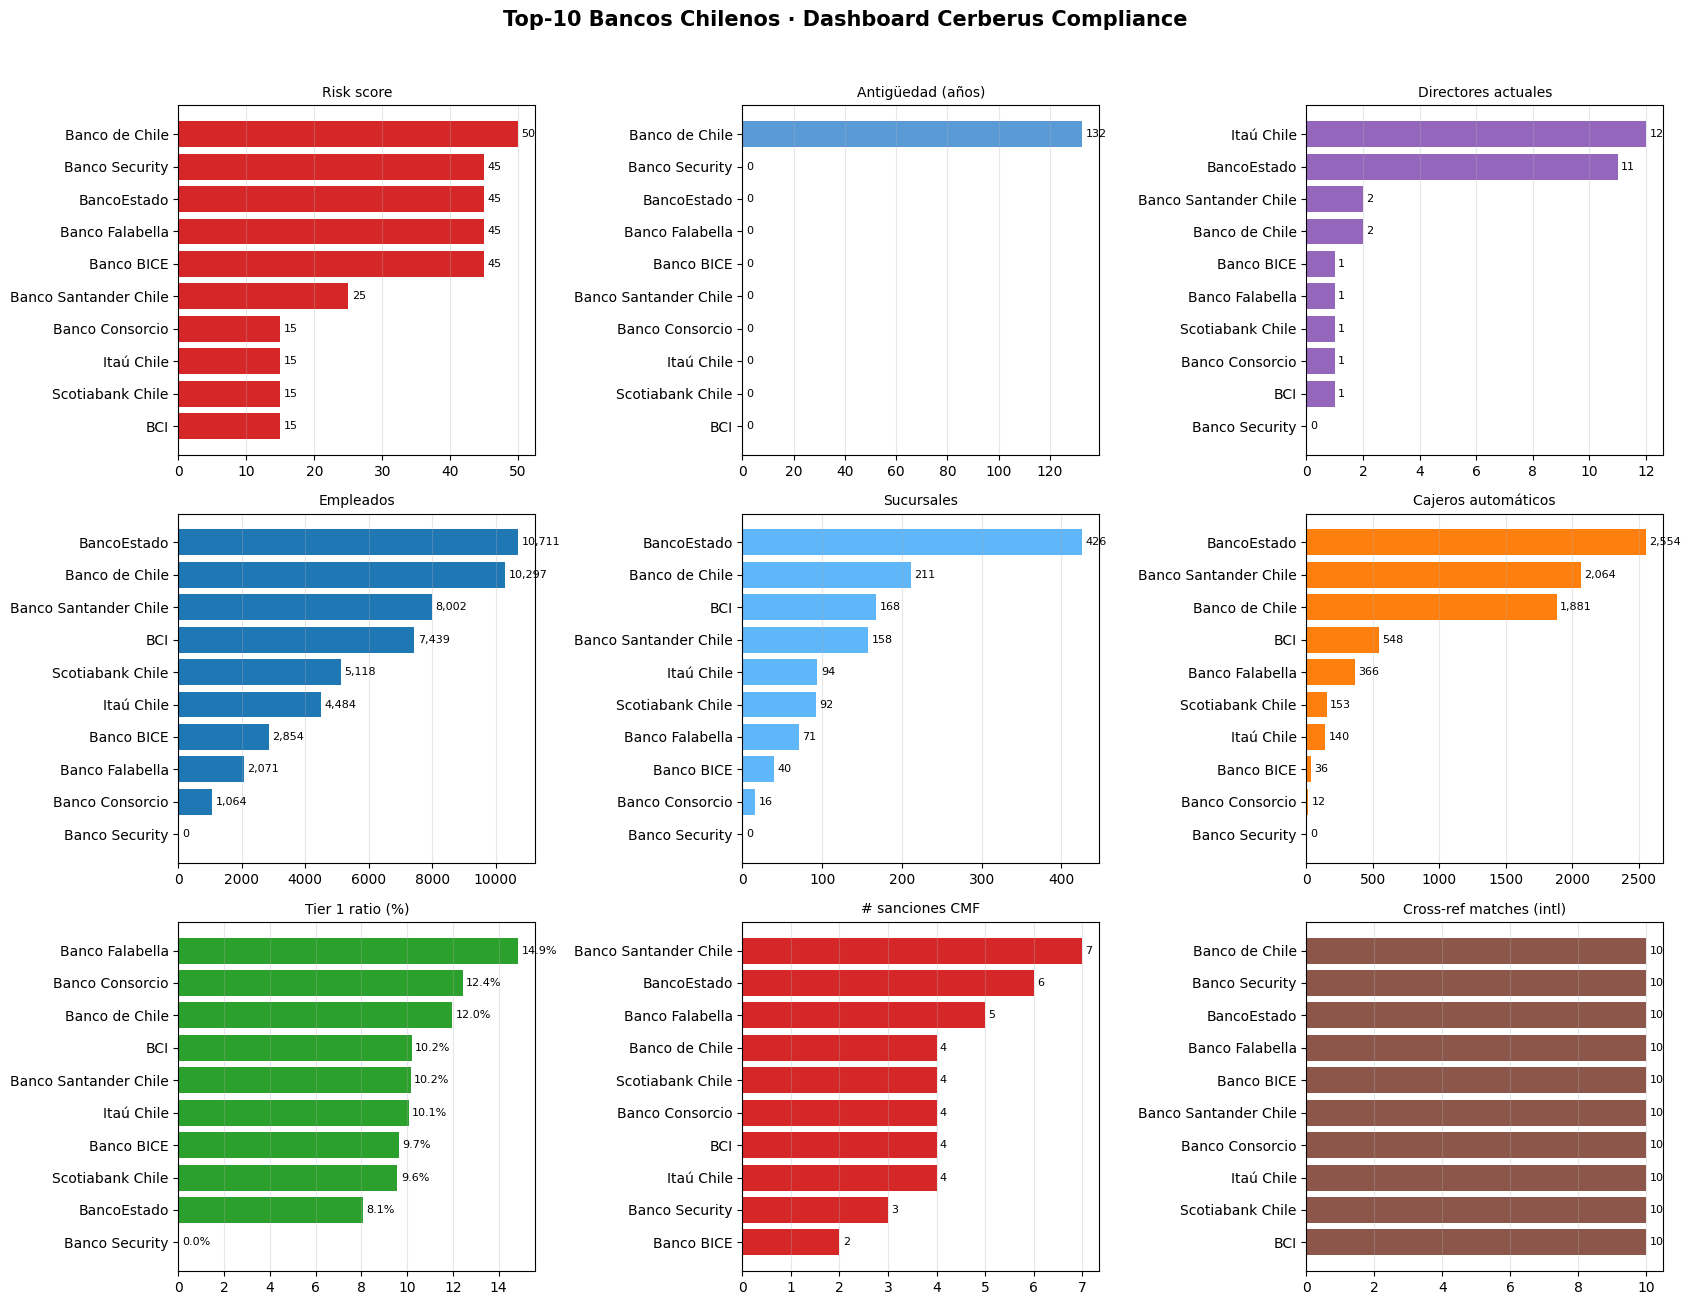

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(17, 13))
fig.suptitle("Top-10 Bancos Chilenos · Dashboard Cerberus Compliance", fontsize=15, weight="bold", y=1.00)

def _bar(ax, series, title, color="#1f77b4", fmt="{:.0f}", show_value=True):
    s = series.dropna().sort_values()
    if len(s) == 0:
        ax.text(0.5, 0.5, f"{title}\n(sin datos)", ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
        return
    ax.barh(s.index, s.values, color=color)
    if show_value:
        for i, v in enumerate(s.values):
            ax.text(v + (s.max() or 1) * 0.01, i, fmt.format(v), va="center", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="x", alpha=0.3)

_bar(axes[0, 0], master["risk_score"],   "Risk score",                 "#d62728", "{:.0f}")
_bar(axes[0, 1], master["age_years"],    "Antigüedad (años)",          "#5b9bd5", "{:.0f}")
_bar(axes[0, 2], master["n_directors"],  "Directores actuales",        "#9467bd", "{:.0f}")
_bar(axes[1, 0], master.get("empleados",  pd.Series()),  "Empleados",          "#1f77b4", "{:,.0f}")
_bar(axes[1, 1], master.get("sucursales", pd.Series()), "Sucursales",          "#5fb6f8", "{:.0f}")
_bar(axes[1, 2], master.get("cajeros",    pd.Series()),  "Cajeros automáticos", "#ff7f0e", "{:,.0f}")
_bar(axes[2, 0], master.get("tier1_pct",  pd.Series()),  "Tier 1 ratio (%)",   "#2ca02c", "{:.1f}%")
_bar(axes[2, 1], master["n_sanciones"],  "# sanciones CMF",            "#d62728", "{:.0f}")
_bar(axes[2, 2], master["xref_n"],       "Cross-ref matches (intl)",   "#8c564b", "{:.0f}")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


## 18 · Resumen — endpoints exprimidos y aprendizajes

| Endpoint SDK | Calls | Para qué |
|---|---:|---|
| `kyb.get(include=…)` | 10 (async, conc=5) | Perfil + directores + LEI + hechos |
| `entities.by_rut` + `entities.ownership` | 20 (async, conc=5) | Cross-check del LEI gap |
| `entities.by_rut` + `entities.sanctions` | 20 (async, conc=5) | Sanciones detalladas por banco |
| `entities.bancos_fichas_latest_per_section` | 10 (async, conc=5) | Accionistas / capital / perfil / integrantes |
| `sanctions.cross_reference` | 10 (async, **conc=3**) | OFAC/UN/EU/CMF · throttled |
| `search.search` | 3 | Semántica banking-specific |
| `indicadores.history` | 4 | UF/USD/TPM/IPC 12m |

**Total**: ~77 llamadas a la API live, completadas sin retries
gracias al throttling.

### Aprendizajes operacionales

1. **El `cross_reference` es el endpoint más caro** — 3 concurrentes es
   el sweet spot. Más de eso → retries automáticos del SDK; menos de eso
   → tiempo total mayor sin beneficio.
2. **El gap de LEI (9/10 bancos sin LEI registrado)** no es del SDK sino
   del backend: el `gleif_refresh` async no completó su run para esos
   RUTs. Verificable cruzando con `entities.ownership` (también vacío).
3. **La cobertura de fichas es asimétrica** — algunos bancos tienen
   las 4 secciones SBIF, otros solo 1-2. La sección §16 hace transparente
   esta asimetría por banco.
4. **El logger del SDK loguea cada retry como WARNING** — útil en
   producción para detectar back-pressure sostenido, pero ruidoso en un
   notebook. Con `logging.getLogger('cerberus_compliance').setLevel(ERROR)`
   se silencia sin perder visibilidad de errores reales.

### Cleanup


In [27]:
print("notebook completo · todos los recursos cerrados via context managers")


notebook completo · todos los recursos cerrados via context managers


---

🐍🔱 **Cerberus SDK · Top-10 Bancos Chilenos** · 2026-04-28
